In [1]:
import seaborn as sns
import pandas as pd

In [6]:
df = sns.load_dataset('titanic')

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [9]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
# duplicated row count inside the data. 

df.duplicated().value_counts()

False    784
True     107
Name: count, dtype: int64

In [12]:
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().value_counts()

False    784
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    str     
 3   age          678 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     782 non-null    str     
 8   class        784 non-null    category
 9   who          784 non-null    str     
 10  adult_male   784 non-null    bool    
 11  deck         202 non-null    category
 12  embark_town  782 non-null    str     
 13  alive        784 non-null    str     
 14  alone        784 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 77.0 KB


In [17]:
df['age'].describe()

count    678.000000
mean      29.869351
std       14.759076
min        0.420000
25%       20.000000
50%       28.250000
75%       39.000000
max       80.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

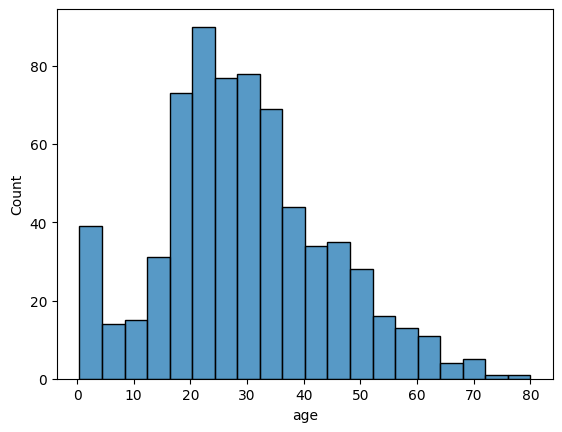

In [18]:
# histogram on total_bill column

sns.histplot(df['age'],bins=20)

<Axes: ylabel='age'>

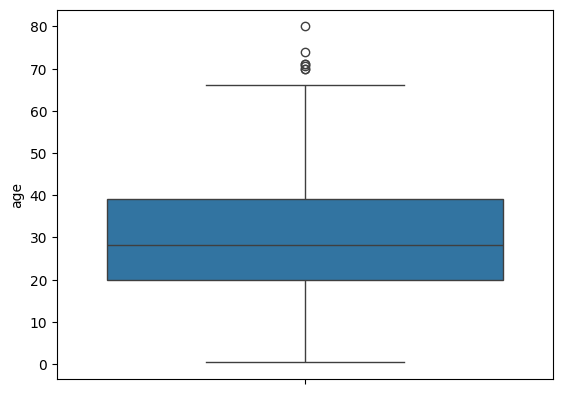

In [19]:
sns.boxplot(df['age'])

In [24]:
q1=df['age'].describe()['25%']
q2=df['age'].describe()['75%']
print(q2-q1)
v1=q2+(q2-q1)*1.5
print(v1)

19.0
67.5


In [25]:
# Outliers valid or not.

df[df['age'] > 40]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
15,1,2,female,55.0,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
35,0,1,male,42.0,1,0,52.0000,S,First,man,True,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,1,1,female,48.0,0,0,25.9292,S,First,woman,False,D,Southampton,yes,True
865,1,2,female,42.0,0,0,13.0000,S,Second,woman,False,NaN,Southampton,yes,True
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
873,0,3,male,47.0,0,0,9.0000,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Density'>

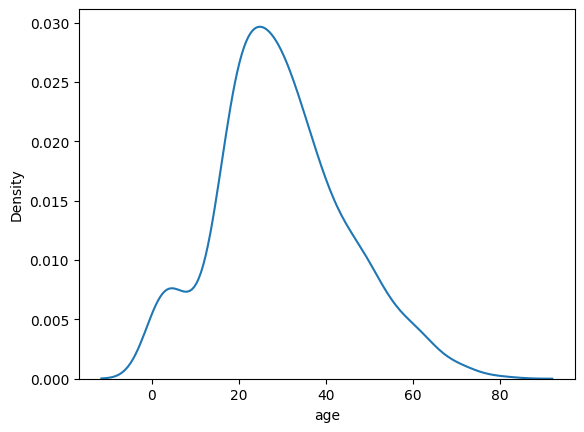

In [26]:
sns.kdeplot(df['age'])

In [27]:
df['age'].skew()

np.float64(0.3674542095476674)

In [29]:
df['pclass'].describe()

count    784.000000
mean       2.243622
std        0.855056
min        1.000000
25%        1.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: pclass, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

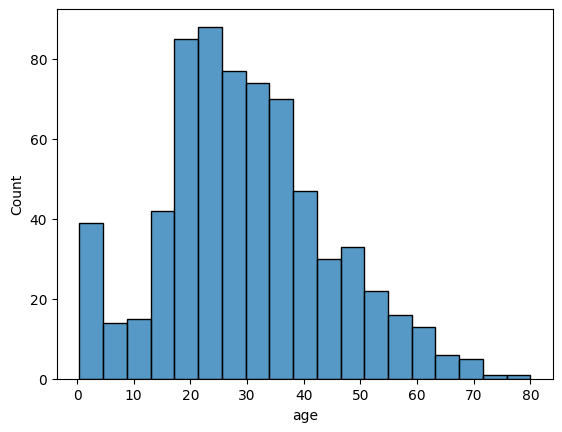

In [30]:
sns.histplot(df['age'])

<Axes: ylabel='embarked'>

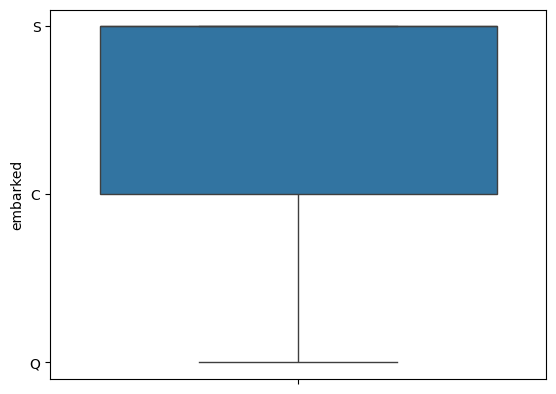

In [33]:
sns.boxplot(df['embarked'])

In [35]:
df[df['pclass'] > 4]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


<Axes: xlabel='pclass', ylabel='Density'>

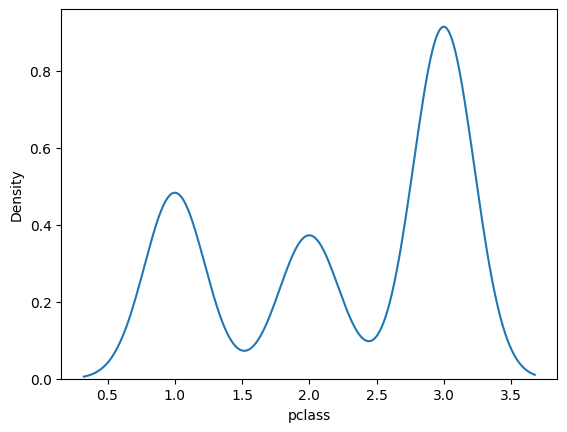

In [36]:
sns.kdeplot(df['pclass'])

In [37]:
df['pclass'].skew()

np.float64(-0.48896565648049745)

In [38]:
df['sex'].value_counts()

sex
male      491
female    293
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='count'>

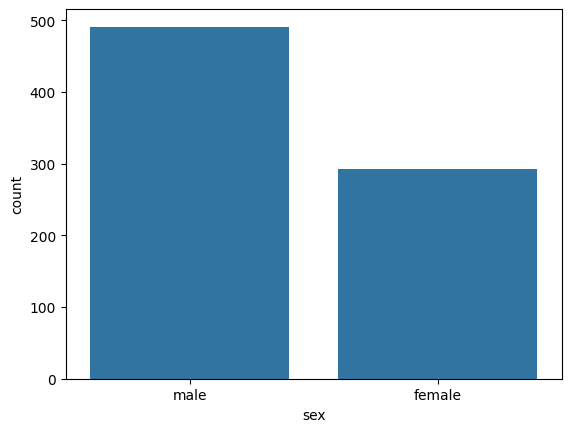

In [39]:
sns.barplot(df['sex'].value_counts())

<Axes: >

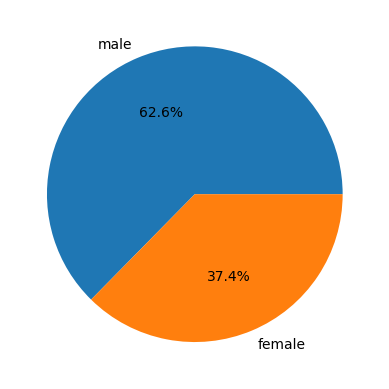

In [40]:
# piechart

df['sex'].value_counts().plot(kind='pie',autopct='%0.01f%%')